Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - loss: 0.0078
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0014
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 9.7138e-04
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 6.1913e-04
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 5.8479e-04
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 3.9105e-04
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 4.6550e-04
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 7.7536e-04
Epoch 9/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 3.1297e-04
Epoch 10/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 5.1670e-04
Epoch 11/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 4.2175e-04
Epoch 12/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 3.5578e-04
Epoch 13/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 2.7813e-04
Epoch 14/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 3.292

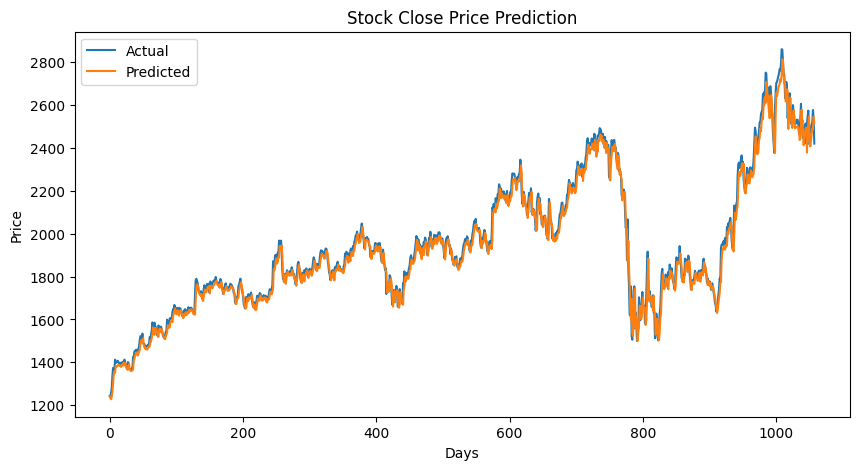

In [85]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
import matplotlib.pyplot as plt

# 1. Load stock data
df = pd.read_csv("C:/Users/hp/Downloads/stock_data/HDFC.csv")
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

# 2. Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 3. Sequence creation
seq_len = 20
X, y = [], []
for i in range(len(scaled_data) - seq_len):
    X.append(scaled_data[i:i + seq_len])
    y.append(scaled_data[i + seq_len][3])  # Predicting 'Close' price
X, y = np.array(X), np.array(y)

# 4. Train/Test split
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 5. Model definition
model = Sequential([
    tf.keras.layers.Input(shape=(seq_len, 5)),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# 6. Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# 7. Predict & inverse transform
pred_scaled = model.predict(X_test)
# Get scaler for only 'Close' column (index 3)
close_scaler = MinMaxScaler()
close_scaler.min_, close_scaler.scale_ = scaler.min_[3], scaler.scale_[3]
predicted = close_scaler.inverse_transform(pred_scaled)
actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# 8. Evaluate
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# 9. Plot
plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.title("Stock Close Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()


In [89]:
model.save("hdfc_lstm_model.keras")